In [1]:
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from streamtracer import StreamTracer, VectorGrid

def xyzmap_relative_error(train_b, ref_b, index, xyz_axis):
    #(64, 64, 64, 3)
    diff = np.linalg.norm(train_b - ref_b, axis=-1)  
    norm = np.linalg.norm(ref_b, axis = -1) +  1e-8 
    relative_error = diff/norm

    # --- z固定の2Dスライスを取り出し ---
    if xyz_axis == 0:
        relative_error_slice = relative_error[:, index, :]  # (64,64)
    else:
        relative_error_slice = relative_error[:, :, index]
    

    print(relative_error_slice.shape)
    # --- 可視化 ---
    plt.figure(figsize=(6,5))
    plt.imshow(relative_error_slice.T, origin="lower", cmap="inferno", vmin = 0, vmax = 1.5)
    plt.colorbar(label="Relative Error")
    plt.title(f"Relative Error (z={index})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
    return relative_error_slice

def bitmap_relative_error(train_b, ref_b, index, thresholds, xyz_axis):
    #(64, 64, 64, 3)
    correct_num = 0
    diff = np.linalg.norm(train_b - ref_b, axis=-1)  
    norm = np.linalg.norm(ref_b, axis = -1) +  1e-8 
    relative_error = diff/norm

    # --- z固定の2Dスライスを取り出し ---
    if xyz_axis == 0:
        relative_error_slice = relative_error[index, :, :]  # (64,64)
    elif xyz_axis == 1:
        relative_error_slice = relative_error[:, index, :]  # (64,64)
    else:
        relative_error_slice = relative_error[:, :, index]
    
    for i in range(64):
        for j in range(64):
            if relative_error_slice[i, j]<thresholds:
                relative_error_slice[i, j] = 1
                correct_num += 1

            else:
                relative_error_slice[i, j] = 0
    plt.figure(figsize=(6,5))
    plt.imshow(relative_error_slice.T, origin="lower", cmap="inferno")
    plt.colorbar(label="Relative Error")
    plt.title(f"Relative Error (z={index})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
    print(correct_num/(64*64))


def box_liner(b):
    #(64, 64, 64, 3)
    stride = 1
    mask = np.abs(b[:, :, 0, 2]) > 400
    seeds = np.stack([np.where(mask == True)[0], 
                    np.where(mask == True)[1], 
                    np.zeros_like(np.where(mask == True)[0])], axis=1)
    seeds = seeds[::stride]
    seeds.shape

    b_resampled = b
    nx, ny, nz, _ = b_resampled.shape
    x = np.arange(nx)
    y = np.arange(ny)
    z = np.arange(nz)

    xv, yv, zv = np.meshgrid(x, y, z, indexing='ij')
    mesh = pv.StructuredGrid(xv, yv, zv)

    bx, by, bz = b_resampled[..., 0], b_resampled[..., 1], b_resampled[..., 2]
    vectors = np.stack([bx, by, bz], axis=-1).transpose(2, 1, 0, 3).reshape(-1, 3)

    mesh["vector"] = vectors
    mesh.active_vectors_name = "vector"

    xx, yy = np.meshgrid(x, y, indexing='ij')
    seeds_xs = np.stack([xx[seeds[:, 0], seeds[:, 1]], 
                        yy[seeds[:, 0], seeds[:, 1]], 
                        np.zeros_like(seeds[:, 0])], axis=1)
    seeds_xs.shape
    pv.global_theme.notebook = True
    pv.global_theme.jupyter_backend = 'static'
    # pv.global_theme.jupyter_backend = 'trame'
    p = pv.Plotter(window_size=(1000, 600))

    p.show_bounds(
        grid='front',
        show_xlabels=False,
        show_ylabels=False,
        show_zlabels=False,
    )
    p.add_mesh(mesh.outline(), color='k')

    seed = pv.PolyData(seeds_xs)
    strl = mesh.streamlines_from_source(seed, vectors='vector', integration_direction='both',
                                        max_time=10000, initial_step_length=0.1)
    p.add_mesh(strl.tube(radius=0.4), color='blue')

    bottom_subset = mesh.extract_subset((0, nx-1, 0, ny-1, 0, 0)).extract_surface()
    p.add_mesh(bottom_subset, cmap='gray', scalars='vector', component=2, clim=(-2000, 2000), 
            lighting=False, show_scalar_bar=False)

    p.camera_position = "xy"
    p.camera.roll = -30
    p.camera.elevation = -70
    p.camera.zoom(1.3)
    p.show()

def curl(b):
    Fx = b[:, :, :, 0]
    Fy = b[:, :, :, 1]
    Fz = b[:, :, :, 2]

    dFz_dy = np.gradient(Fz, axis=1)
    dFy_dz = np.gradient(Fy, axis=2)
    dFx_dz = np.gradient(Fx, axis=2)
    dFz_dx = np.gradient(Fz, axis=0)
    dFy_dx = np.gradient(Fy, axis=0)
    dFx_dy = np.gradient(Fx, axis=1)

    curl_x = dFz_dy - dFy_dz
    curl_y = dFx_dz - dFz_dx
    curl_z = dFy_dx - dFx_dy

    curl = np.stack([curl_x, curl_y, curl_z], axis=-1)  # (64,64,64,3)
    return curl

def ij(b, index):
    j = curl((b))
    ab_j = np.linalg.norm(j, axis=-1)  
    ab_b = np.linalg.norm(b, axis = -1) +  1e-8 
    value = ab_j/ab_b


    relative_error_slice = value[:, :, index]
    
    # --- 可視化 ---
    plt.figure(figsize=(6,5))
    plt.imshow(relative_error_slice.T, origin="lower", cmap="inferno", vmin = 0, vmax = 2.5)
    plt.colorbar(label="|j|/|B|")
    plt.title(f"|j|/|B| (z={index})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
    return relative_error_slice

def divb(b, correct_b, index):
    grads = gradient_vector_field(b, 1, 1, 1)
    div = grads["dBx_dx"] + grads["dBy_dy"] + grads["dBz_dz"]  # (nx, ny, nz)
    div = np.expand_dims(div, axis=-1)  # (nx, ny, nz, 1)
    div = np.repeat(div, 3, axis=-1)    # (nx, ny, nz, 3)
    ab_div = np.linalg.norm(div, axis = -1)
    grads = gradient_vector_field(correct_b, 1, 1, 1)
    div_correct = grads["dBx_dx"] + grads["dBy_dy"] + grads["dBz_dz"]  # (nx, ny, nz)
    div_correct = np.expand_dims(div_correct, axis=-1)  # (nx, ny, nz, 1)
    div_correct = np.repeat(div_correct, 3, axis=-1)    # (nx, ny, nz, 3)
    D = ab_div[:, :, index]
    

    plt.figure(figsize=(6,5))
    plt.imshow(D.T, origin="lower", cmap="inferno", vmin = 0, vmax = 2.5)
    plt.colorbar(label="|div|")
    plt.title(f"|div| (z={index})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
    xyzmap_relative_error(div, div_correct, index, 2)
    return D


def jxb(b, correct_b, index):
    f = np.cross(curl(b), b)
    ab_f = np.linalg.norm(f, axis = -1)
    correct_f = np.cross(curl(correct_b), correct_b)
    F = ab_f[:, :, index]
    

    plt.figure(figsize=(6,5))
    plt.imshow(F.T, origin="lower", cmap="inferno", vmin = 0, vmax = 1.5)
    plt.colorbar(label="|F|")
    plt.title(f"|F| (z={index})")
    plt.xlabel("x index")
    plt.ylabel("y index")
    plt.show()
    xyzmap_relative_error(f, correct_f, index, 2)
    return F



def gradient_vector_field(b, dx=1.0, dy=1.0, dz=1.0):
    """
    B: shape (Nx, Ny, Nz, 3)
    returns: gradients dB/dx, dB/dy, dB/dz each shape (Nx, Ny, Nz, 3)
    """
    dBx_dx = np.gradient(b[..., 0], dx, axis=0)
    dBx_dy = np.gradient(b[..., 0], dy, axis=1)
    dBx_dz = np.gradient(b[..., 0], dz, axis=2)

    dBy_dx = np.gradient(b[..., 1], dx, axis=0)
    dBy_dy = np.gradient(b[..., 1], dy, axis=1)
    dBy_dz = np.gradient(b[..., 1], dz, axis=2)

    dBz_dx = np.gradient(b[..., 2], dx, axis=0)
    dBz_dy = np.gradient(b[..., 2], dy, axis=1)
    dBz_dz = np.gradient(b[..., 2], dz, axis=2)

    return {
        "dBx_dx": dBx_dx, "dBx_dy": dBx_dy, "dBx_dz": dBx_dz,
        "dBy_dx": dBy_dx, "dBy_dy": dBy_dy, "dBy_dz": dBy_dz,
        "dBz_dx": dBz_dx, "dBz_dy": dBz_dy, "dBz_dz": dBz_dz,
    }

def divergence(b, dx=1.0, dy=1.0, dz=1.0):
    grads = gradient_vector_field(b, dx, dy, dz)
    return grads["dBx_dx"] + grads["dBy_dy"] + grads["dBz_dz"]

def curl_2(b, dx=1.0, dy=1.0, dz=1.0):
    grads = gradient_vector_field(b, dx, dy, dz)
    curl_x = grads["dBz_dy"] - grads["dBy_dz"]
    curl_y = grads["dBx_dz"] - grads["dBz_dx"]
    curl_z = grads["dBy_dx"] - grads["dBx_dy"]
    return np.stack([curl_x, curl_y, curl_z], axis=-1)

def omega(b, dx=1.0, dy=1.0, dz=1.0):
    curlB = curl_2(b, dx, dy, dz)                  # (Nx,Ny,Nz,3)
    divB = divergence(b, dx, dy, dz)[..., None]  # shape (...,1) に揃える
    Bnorm2 = np.sum(b**2, axis=-1, keepdims=True) + 1e-12

    term1 = np.cross(curlB, b)
    term2 = divB * b
    return (term1 - term2) / Bnorm2


def grad_scalar(f, dx=1.0, dy=1.0, dz=1.0):
    """
    f: 3D scalar field (Nx, Ny, Nz)
    returns: gradient vector field (Nx, Ny, Nz, 3)
    """
    df_dx = np.gradient(f, dx, axis=0)
    df_dy = np.gradient(f, dy, axis=1)
    df_dz = np.gradient(f, dz, axis=2)
    return np.stack([df_dx, df_dy, df_dz], axis=-1)

def F(B, dx=1.0, dy=1.0, dz=1.0):
    curlB = curl_2(B, dx, dy, dz)
    divB = divergence(B, dx, dy, dz)[..., None]
    Om = omega(B, dx, dy, dz)

    Bnorm2 = np.sum(B**2, axis=-1, keepdims=True) + 1e-12

    # --- 1項目 ---
    term1 = curl_2(np.cross(curlB, B) / Bnorm2 * B, dx, dy, dz)

    # --- 2項目 ---
    term2 = -curl_2(((np.sum(Om * B, axis=-1, keepdims=True)) * B) / Bnorm2, dx, dy, dz)

    # --- その他の項 ---
    term3 = -np.cross(Om, curlB)
    term4 = -grad_scalar(np.sum(Om * B, axis=-1), dx, dy, dz)
    term5 = Om * (np.sum(Om * B, axis=-1, keepdims=True))
    term6 = (np.sum(Om**2, axis=-1, keepdims=True)) * B

    return term1 + term2 + term3 + term4 + term5 + term6

def optimization(b, const, loop):
    f_array = []
    for _ in range(loop):
        f = F(b, 1, 1, 1)  # fも b と同じ形状を返す前提
        f_array.append(f)

        # 更新候補
        b_new = b + const * f

        mask = np.ones_like(b, dtype=bool)

        mask[0, :, :, :] = False      # x=0 面
        mask[-1, :, :, :] = False     # x=nx-1 面
        mask[:, 0, :, :] = False      # y=0 面
        mask[:, -1, :, :] = False     # y=ny-1 面
        mask[:, :, 0, :] = False    # z=0 面
        mask[:, :, -1, :] = False

        b = np.where(mask, b_new, b)
        

    return b, f_array

def trace_optimization(b,  const, f_array):
    for i in range(f_array):
 
        b_new = b + const * f_array[i]

        mask = np.ones_like(b, dtype=bool)

        mask[0, :, :, :] = False      # x=0 面
        mask[-1, :, :, :] = False     # x=nx-1 面
        mask[:, 0, :, :] = False      # y=0 面
        mask[:, -1, :, :] = False     # y=ny-1 面
        mask[:, :, 0, :] = False    # z=0 面
        mask[:, :, -1, :] = False

        b = np.where(mask, b_new, b)

    return b


def potential(b0, dz=1.0):#dzは格子サイズ
    """
    入力:
        Bz0 : (nx, ny) 配列, z=0 における Bz(x,y,0)
        dz  : z方向の格子間隔 (任意に指定)
    出力:
        B : (nx, ny, nz, 3) 配列, (Bx, By, Bz)
    """
    nx, ny = b0.shape
    nz = nx  

    kx = np.fft.fftfreq(nx, d=1.0) * 2*np.pi
    ky = np.fft.fftfreq(ny, d=1.0) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K = np.sqrt(KX**2 + KY**2) + 1e-12  # 0除算防止

    # Bz0 のフーリエ変換
    b0_k = np.fft.fft2(b0)

    # 出力格納用
    b = np.zeros((nx, ny, nz, 3), dtype=np.float64)

    # 各 z 平面について逆変換
    for iz in range(nz):
        z = iz * dz
        decay = np.exp(-K * z)

        bx_k = b0_k * (-1j * KX / K) * decay
        by_k = b0_k * (-1j * KY / K) * decay
        bz_k = b0_k * decay

        bx = np.fft.ifft2(bx_k).real
        by = np.fft.ifft2(by_k).real
        bz = np.fft.ifft2(bz_k).real

        b[:, :, iz, 0] = bx
        b[:, :, iz, 1] = by
        b[:, :, iz, 2] = bz

    return b




['b']
(64, 64, 64, 3)
b (64, 64, 64, 3) float64


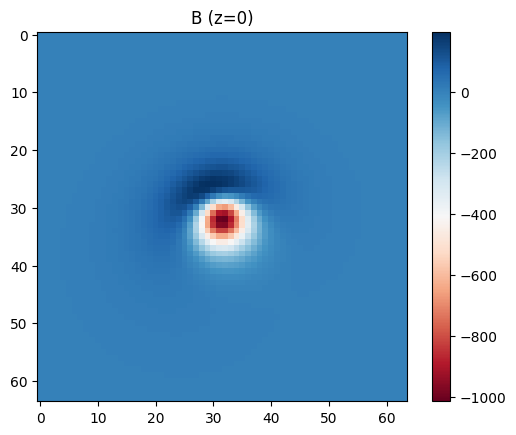

torch.Size([1, 64, 64, 64, 3])
(64, 64, 64, 3)


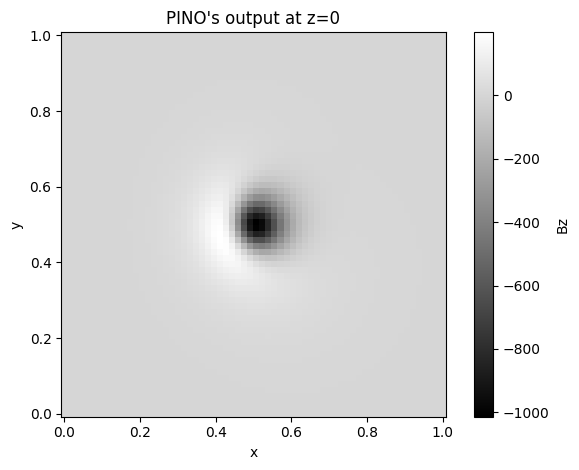

/tmp/ipykernel_2069065/3139351258.py:67: UserWarning: Adding colorbar to a different Figure <Figure size 640x480 with 2 Axes> than <Figure size 640x480 with 2 Axes> which fig.colorbar is called on.
  fig.colorbar(pcm, ax=ax, label="Bz")


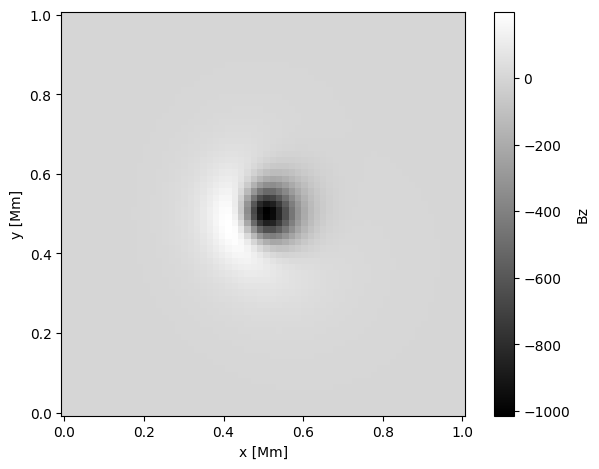

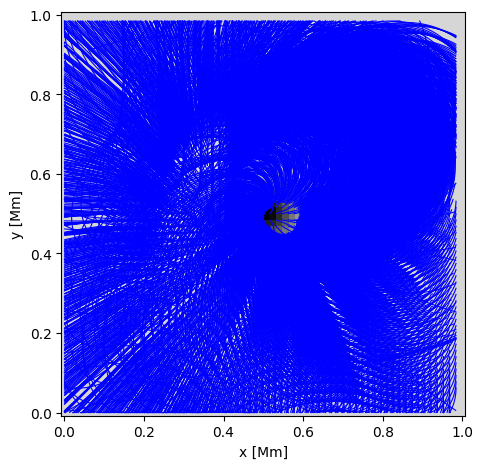

In [2]:
lowlou_f = "/workspaces/template_pytorch/rtmag/lowlou/test/b_0.210_0.124.npz"
data = np.load(lowlou_f)


print(data.files)  

b = data["b"]
correct_data = b
print(b.shape)


with np.load(lowlou_f) as data:
    for key in data.files:
        print(key, data[key].shape, data[key].dtype)

import matplotlib.pyplot as plt

bx = b[..., 0]  # x成分 (64,64,64)
by = b[..., 1]  # y成分 (64,64,64)
bz = b[..., 2]  # z成分 (64,64,64)
k = 0 
plt.imshow(bz[:, :, k], cmap="RdBu")
plt.colorbar()
plt.title("B (z=0)")
plt.show()

import torch
b_tensor = torch.from_numpy(b)
b_tensor = b_tensor.unsqueeze(0)


print(b_tensor.shape)



bottom = b[:, :, 0, :]

nx, ny, nz = bx.shape
x = np.linspace(0, 1, nx)  # 単位はあとで変換できる
y = np.linspace(0, 1, ny)

X, Y = np.meshgrid(x, y, indexing="ij")
bottom = bz[:, :, 0]   # z=0平面の Bz
print(b.shape)

# bottom はすでに (64,64)
fig, ax = plt.subplots()
pcm = ax.pcolormesh(X, Y, bottom, cmap='gray')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_aspect('equal')
ax.set_title("PINO's output at z=0")

fig.colorbar(pcm, ax=ax, label="Bz")  
plt.tight_layout()
plt.show()

from streamtracer import StreamTracer, VectorGrid

mask = np.abs(bottom) > 1
fig, ax = plt.subplots()
ax.pcolormesh(x, y, (bottom*mask).T, cmap='gray')
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
fig.colorbar(pcm, ax=ax, label="Bz")  
plt.tight_layout()
plt.show()

stride = 1
seeds = np.stack([np.where(mask == True)[0], 
                  np.where(mask == True)[1], 
                  np.zeros_like(np.where(mask == True)[0])], axis=1)
seeds = seeds[::stride]
seeds.shape

nsteps = 10000
step_size = 0.1
grid_spacing = [1, 1, 1]

grid = VectorGrid(b.astype(np.float64), grid_spacing)
tracer = StreamTracer(nsteps, step_size)
tracer_xs = []
tracer.trace(seeds, grid)
tracer_xs.append(tracer.xs)
tracer_xs = [item for sublist in tracer_xs for item in sublist]

dx = 1/64
dy = 1/64

fig, ax = plt.subplots()
ax.pcolormesh(x, y, bottom.T, cmap='gray')
ax.set_xlabel('x [Mm]')
ax.set_ylabel('y [Mm]')
ax.set_aspect('equal')
for i, xl in enumerate(tracer_xs):
    assert seeds[i] in xl 
    ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
plt.tight_layout()
plt.show()

(64, 64, 64, 3)
(1, 64, 64, 64, 3)
(1, 1, 64, 64, 3)
Processing model: /workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/model_20.pt
Model loaded from epoch 20
b_norm = 200 G
cuda:0
0.26256632804870605 seconds
(64, 64, 64, 3) (44, 3)
[[[[-1.88702047e+00 -2.44902229e+00 -1.91538477e+00]
   [-1.54799724e+00 -1.95112169e+00 -1.06172431e+00]
   [-1.35170078e+00 -1.05789053e+00 -9.48850811e-01]
   ...
   [-1.09995514e-01  1.83879845e-02 -1.06920831e-01]
   [-5.37396893e-02  5.15919104e-02 -1.23815641e-01]
   [-7.73502514e-02  1.12758055e-01 -1.32839471e-01]]

  [[-2.04552126e+00 -2.57916903e+00 -1.41872168e+00]
   [-1.56311715e+00 -1.98602319e+00 -6.31480455e-01]
   [-1.41232157e+00 -1.32667375e+00 -5.06734371e-01]
   ...
   [-1.37764812e-01  4.25430797e-02 -8.11084360e-02]
   [-7.97214508e-02  8.01874325e-02 -1.02648705e-01]
   [-1.09702207e-01  1.25682995e-01 -1.19537570e-01]]

  [[-2.25174713e+00 -2.77787161e+00 -1.26638412e+00]
   [-1.81819522e+00 -2.21249485e+00 -4.2691

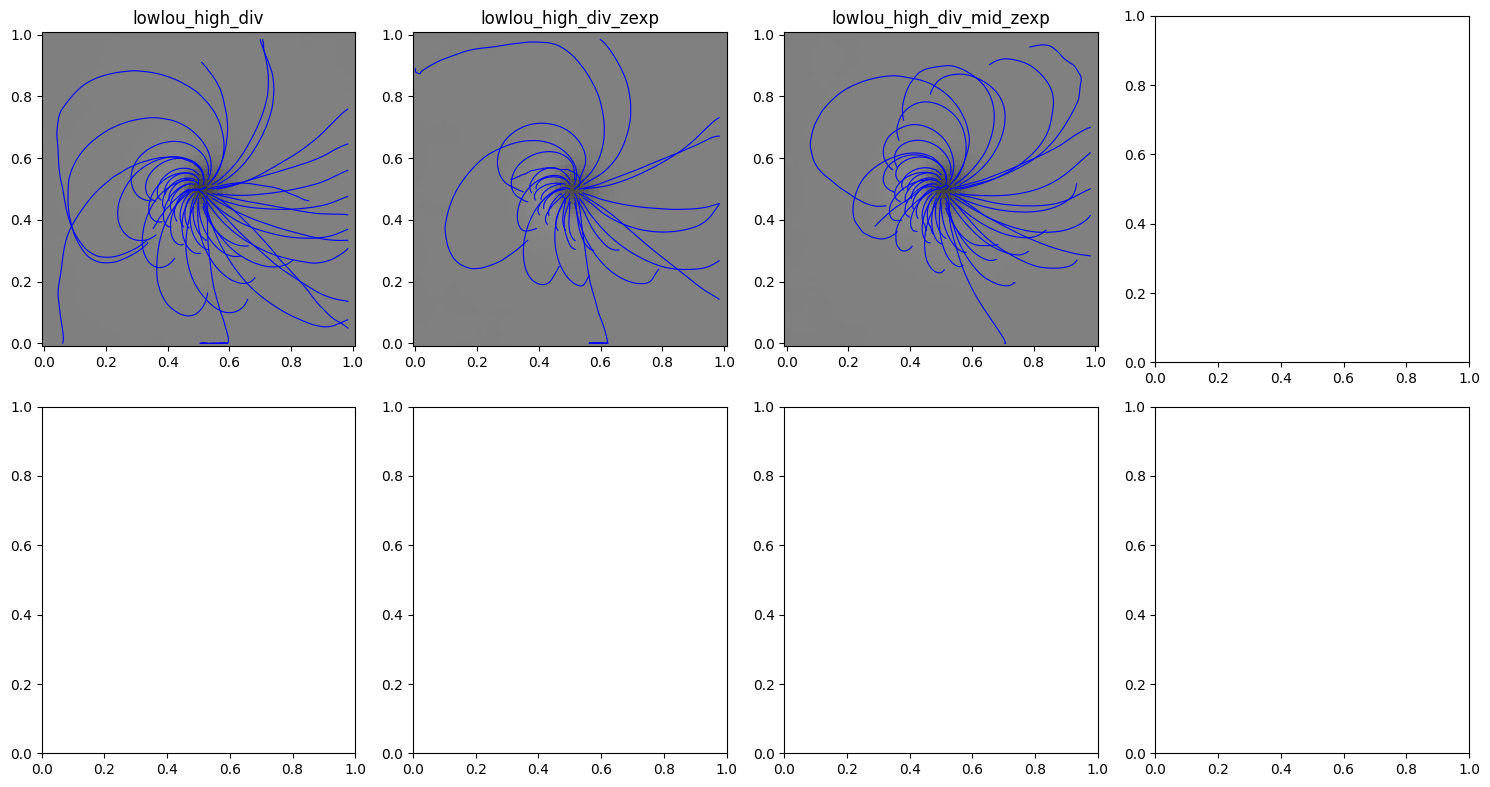

In [3]:
import torch
from rtmag.process.paper.load import MyModel
from streamtracer import StreamTracer, VectorGrid
import os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# モデルパス一覧
paths = [
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/best_model.pt", 
   
   ]
paths = [
    "/workspaces/template_pytorch/rtmag-main_z/D:/models/lowlou_high_div_avg_zexp/model_10.pt" 
   
   ]


paths = [
    "/workspaces/template_pytorch/rtmag-main/D:/models/lowlou_high_div/model_20.pt",
    "/workspaces/template_pytorch/rtmag-main_z/D:/models/lowlou_high_div_zexp/model_20.pt",
    "/workspaces/template_pytorch/rtmag-main_z/D:/models/lowlou_high_div_mid_zexp/model_19.pt"
]






results = [] 
b_array = []

# b_tensor: torch.Size([1, 64, 64, 64, 3])

# Tensor のまま transpose
print(b.shape)
b = np.expand_dims(b, axis=0)
b = np.transpose(b, (0, 3, 2, 1, 4))
print(b.shape)
b = b[:, 0:1, :, :, :]
print(b.shape)
model_input = b


for idx, meta_path in enumerate(paths):
    print(f"Processing model: {meta_path}")
    mm = MyModel(meta_path, device=device)

    # 予測
    b = mm.get_pred_from_numpy(model_input)
    b_array.append(b)
    

    # z=0 の Bz 成分
    bottom = b[:, :, 0, 2]
    mask = np.abs(bottom) > 400

    # シード点作成
    seeds = np.stack([
        np.where(mask == True)[0], 
        np.where(mask == True)[1], 
        np.zeros_like(np.where(mask == True)[0])
    ], axis=1)
    seeds = seeds[::stride]
    print(b.shape, seeds.shape)
    print(b)

    # 流線追跡
    grid = VectorGrid(b.astype(np.float64), grid_spacing)
    tracer = StreamTracer(nsteps, step_size)
    tracer_xs = []
    tracer.trace(seeds, grid)
    tracer_xs.append(tracer.xs)
    tracer_xs = [item for sublist in tracer_xs for item in sublist]

    # 個別図を保存
    fig, ax = plt.subplots()
    ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
    ax.set_xlabel('x [Mm]')
    ax.set_ylabel('y [Mm]')
    ax.set_aspect('equal')
    for i, xl in enumerate(tracer_xs):
        assert seeds[i] in xl
        ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
    ax.set_title(f"Model {idx+1}")
    plt.tight_layout()
    plt.savefig(f"model_{idx+1}.png")
    plt.close(fig)

    # まとめ出力用に保存
    results.append((bottom, tracer_xs, seeds))

# ===== まとめ図を作成 =====
fig, axes = plt.subplots(2, 4, figsize=(15, 8))

for idx, (bottom, tracer_xs, seeds) in enumerate(results):
    ax = axes.flat[idx]
    ax.pcolormesh(x, y, bottom.T, cmap='gray', vmin=-2000, vmax=2000)
    ax.set_aspect('equal')
    for i, xl in enumerate(tracer_xs):
        ax.plot(xl[:,0]*dx+x[0], xl[:,1]*dy+y[0], color='blue', linewidth=0.8)
    model_name = os.path.basename(os.path.dirname(paths[idx]))
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

/usr/local/lib/python3.12/dist-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/core/filters/data_set.py:3204: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


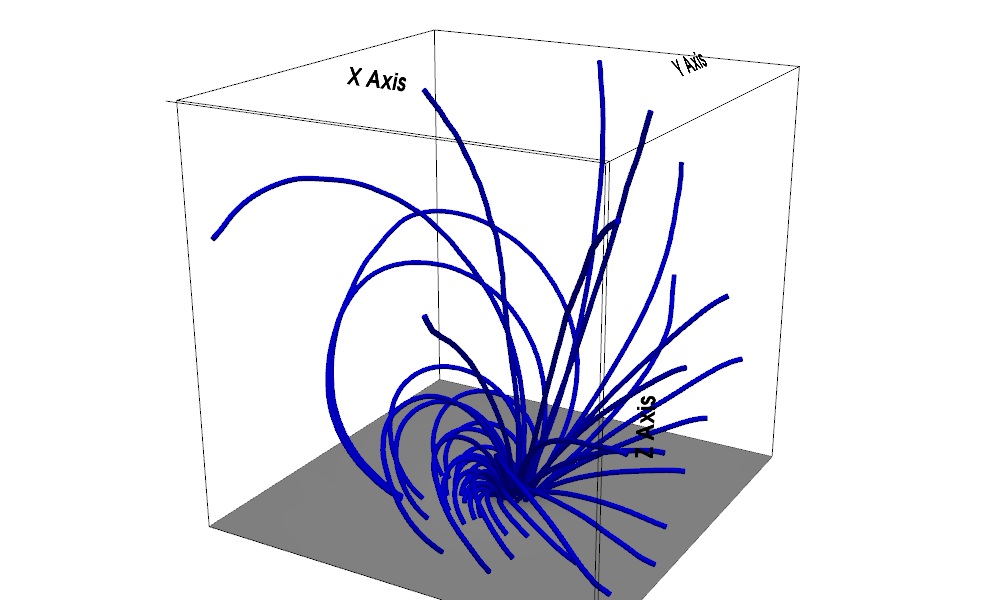

/usr/local/lib/python3.12/dist-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/core/filters/data_set.py:3204: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


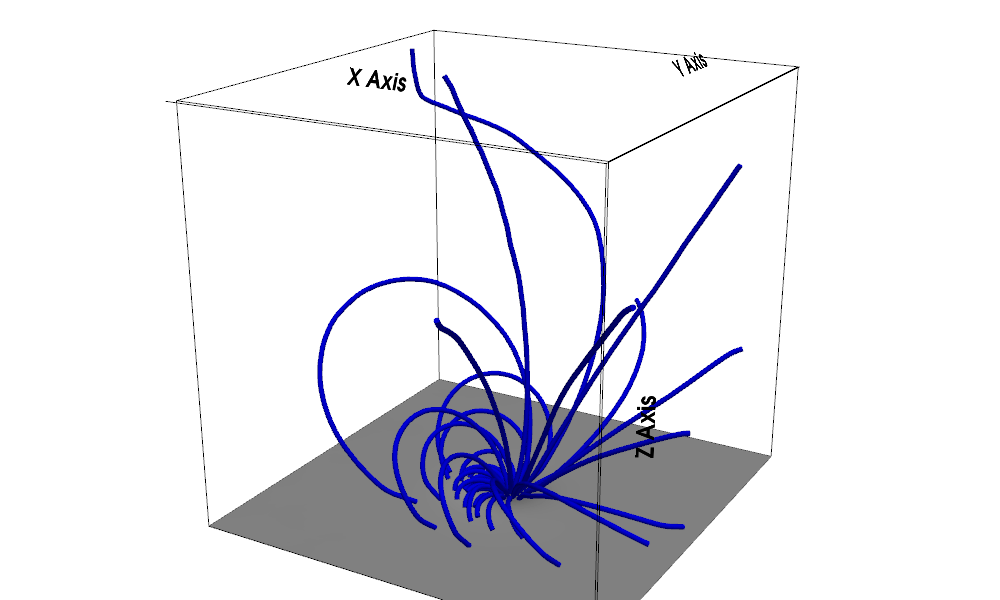

/usr/local/lib/python3.12/dist-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/core/filters/data_set.py:3204: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


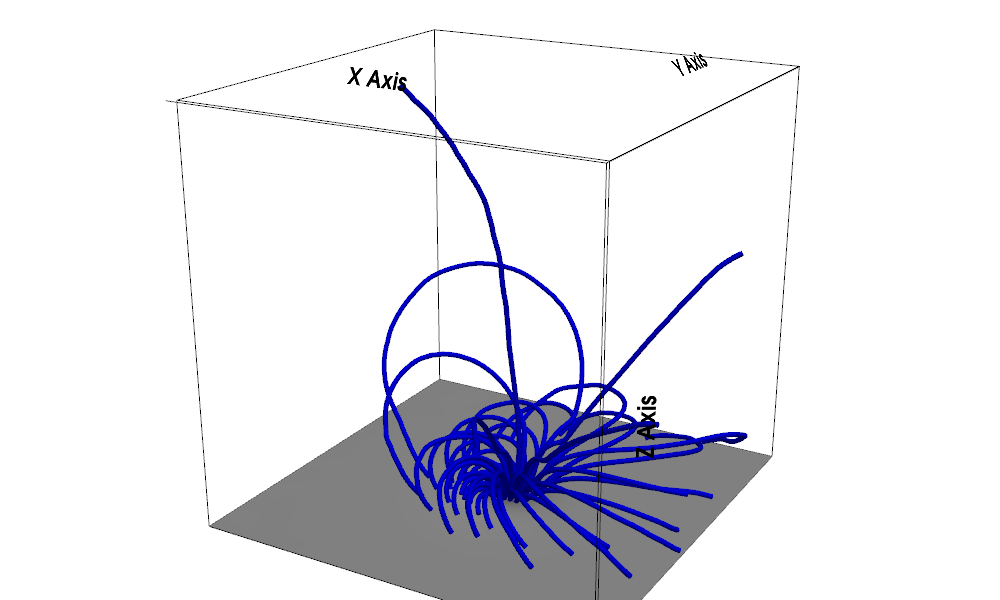

/usr/local/lib/python3.12/dist-packages/pyvista/core/utilities/points.py:79: UserWarning: Points is not a float type. This can cause issues when transforming or applying filters. Casting to ``np.float32``. Disable this by passing ``force_float=False``.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyvista/core/filters/data_set.py:3204: PyVistaDeprecationWarning: ``max_time`` parameter is deprecated.  It will be removed in v0.48
  warnings.warn(


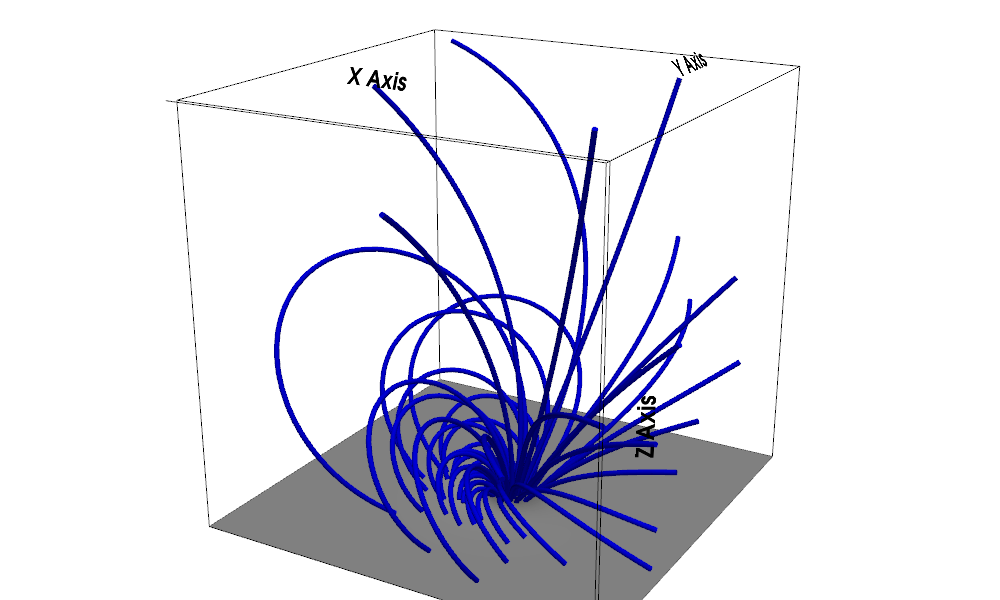

In [4]:
b_array.append(correct_data)

for i in range(len(b_array)):
    box_liner(b_array[i])

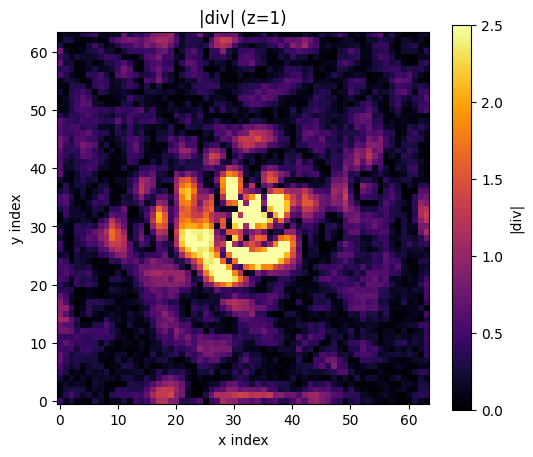

(64, 64)


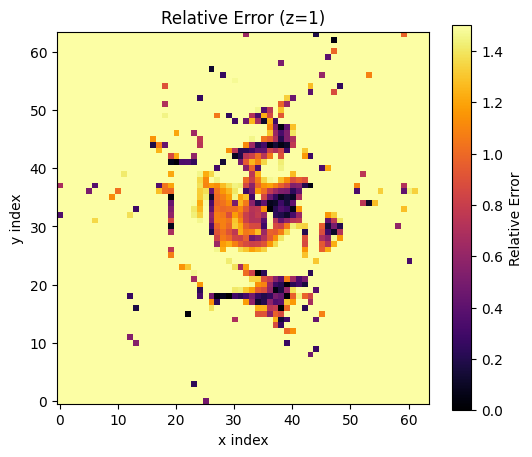

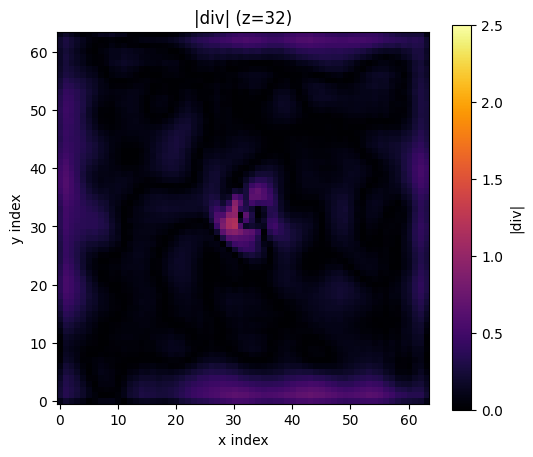

(64, 64)


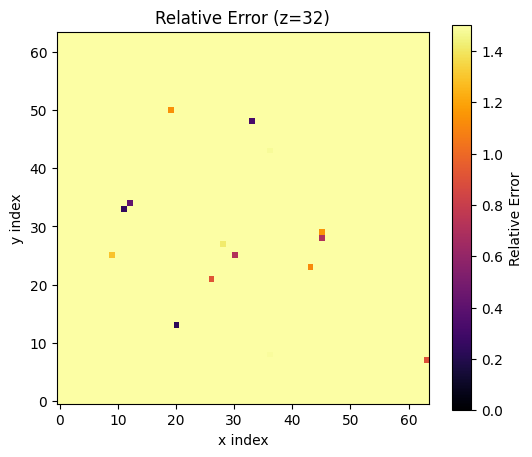

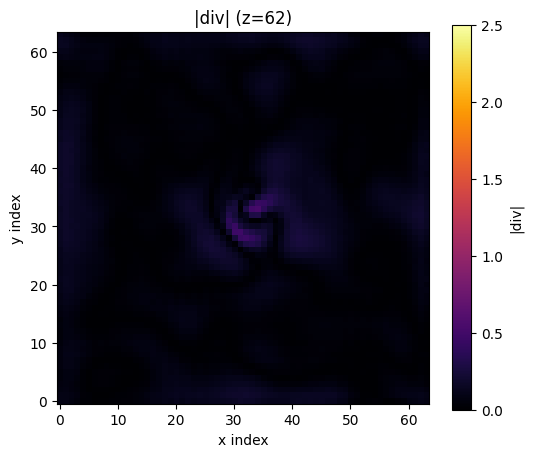

(64, 64)


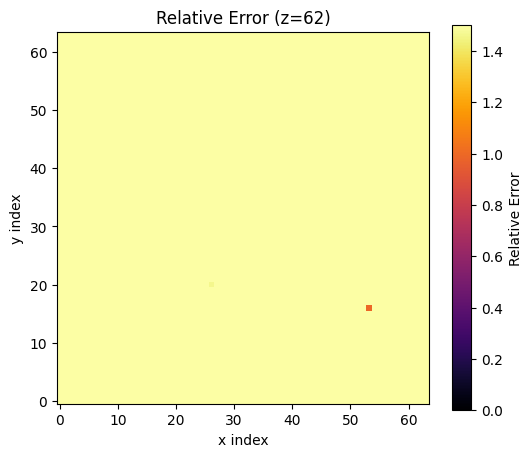

(64, 64)


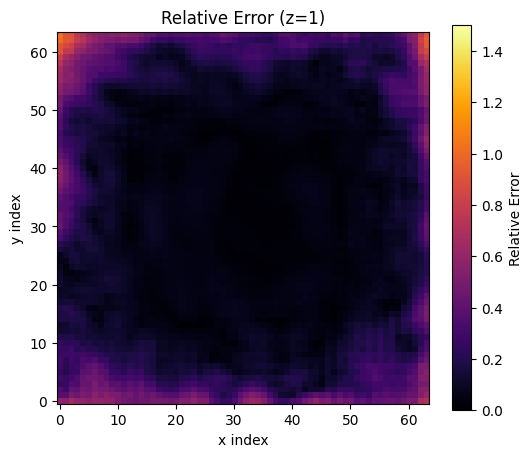

(64, 64)


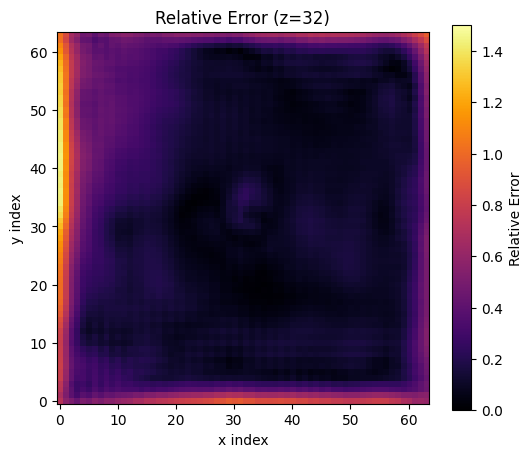

(64, 64)


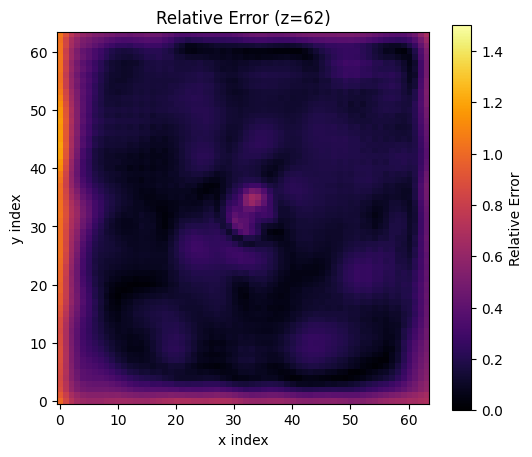

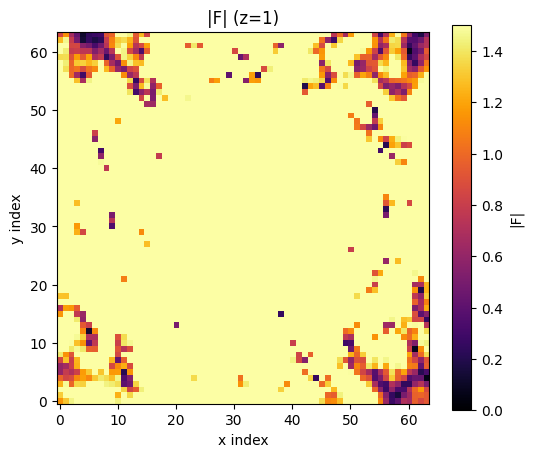

(64, 64)


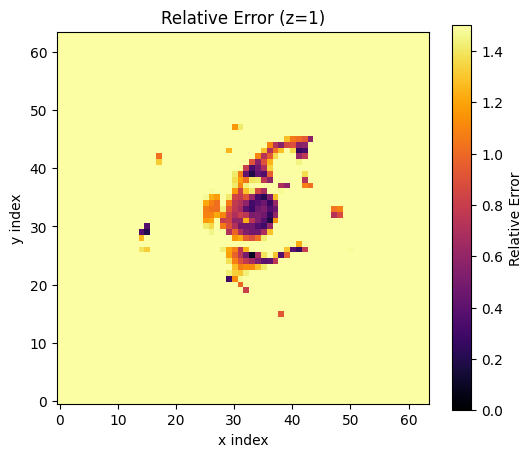

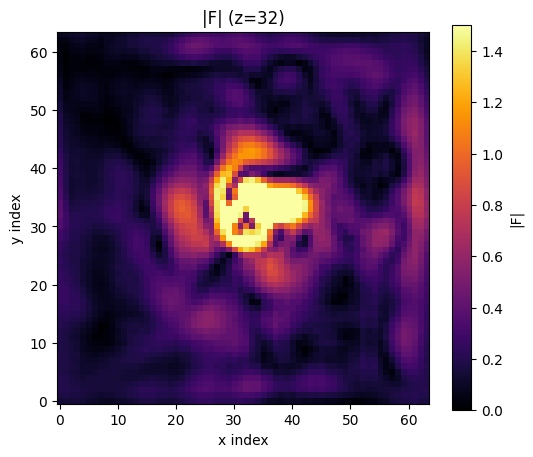

(64, 64)


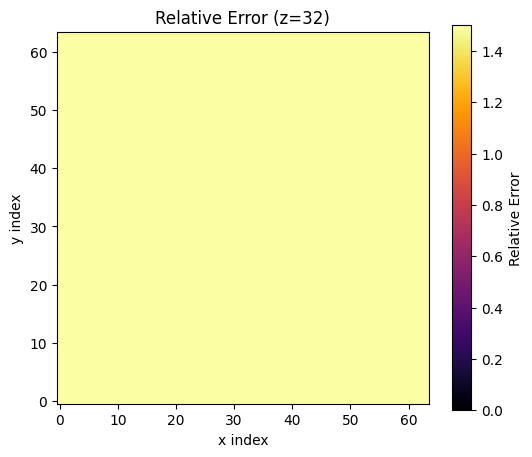

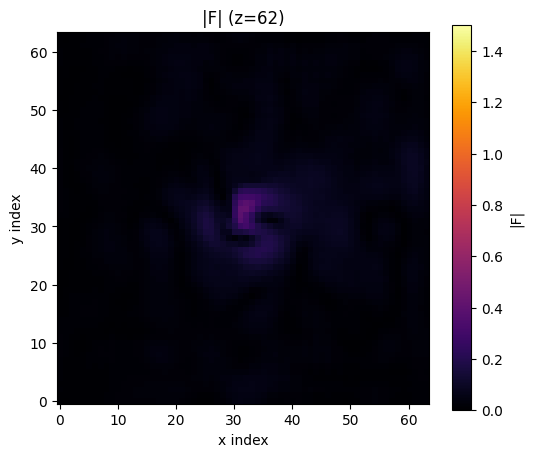

(64, 64)


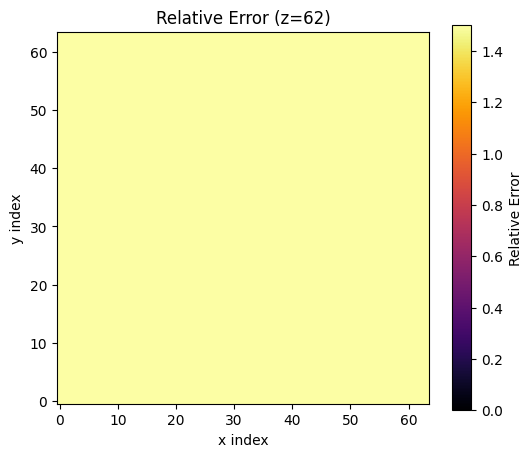

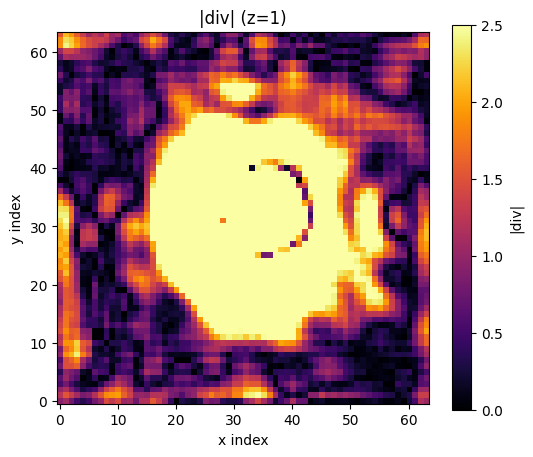

(64, 64)


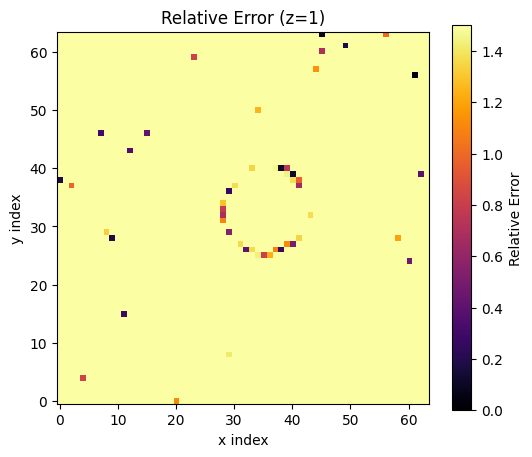

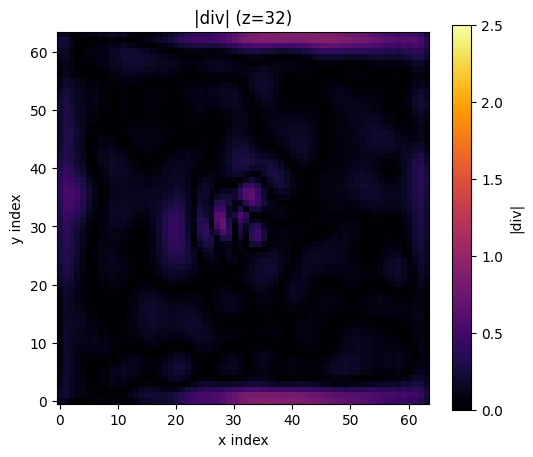

(64, 64)


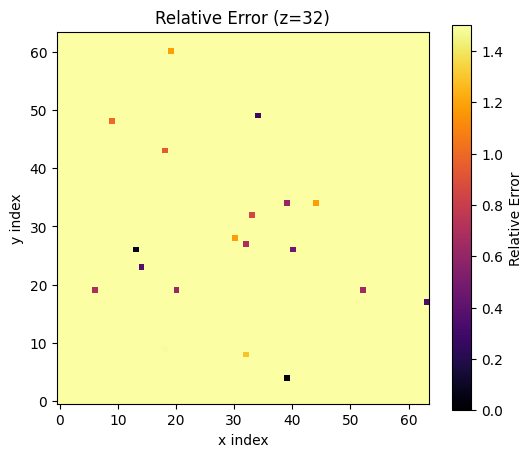

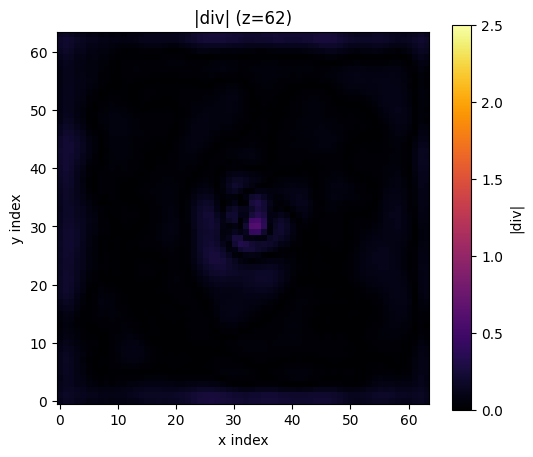

(64, 64)


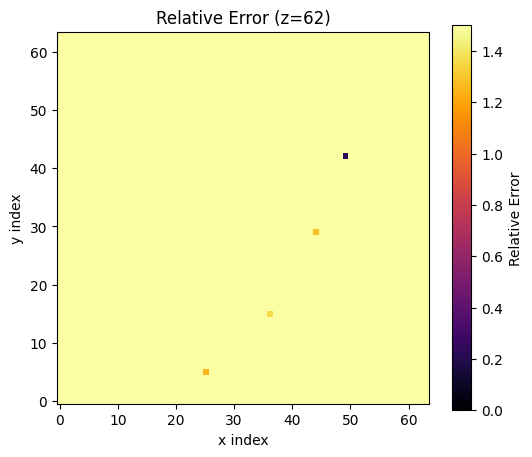

(64, 64)


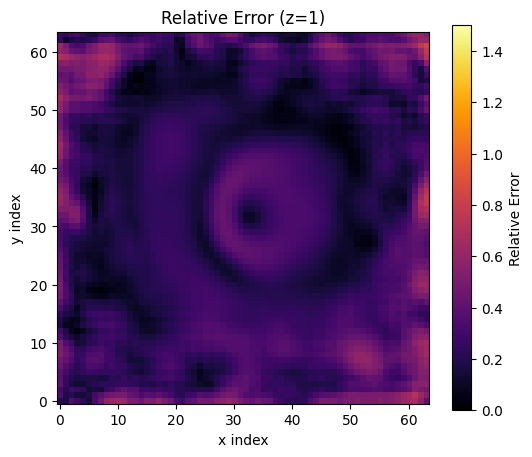

(64, 64)


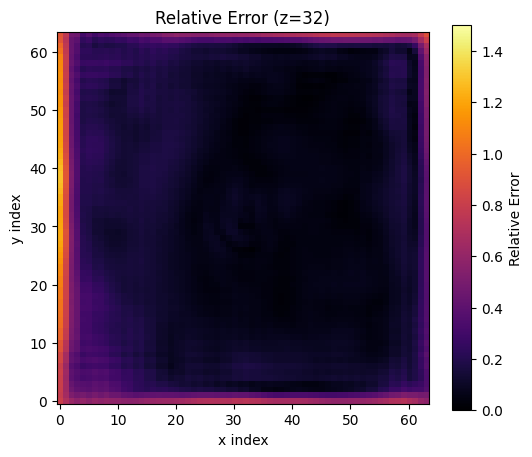

(64, 64)


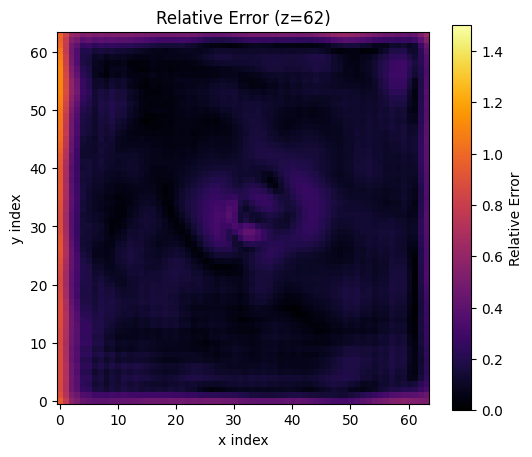

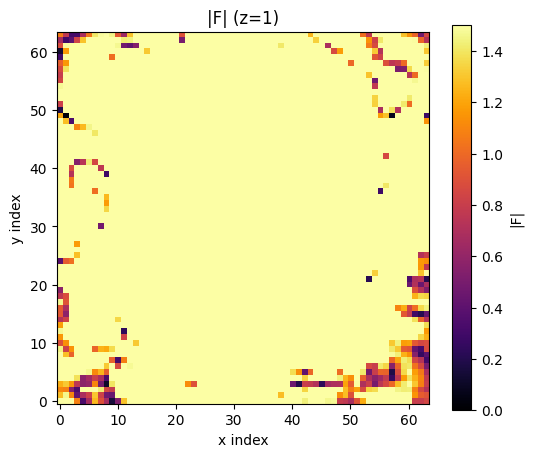

(64, 64)


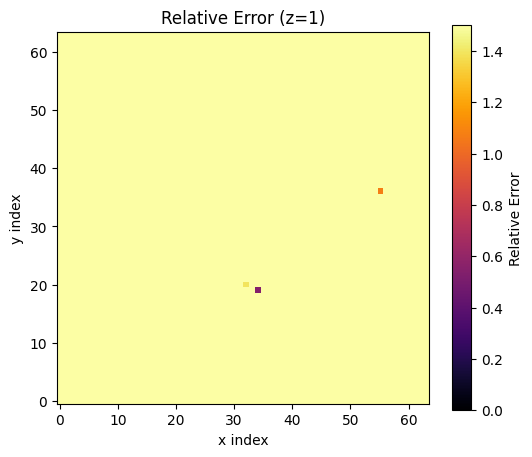

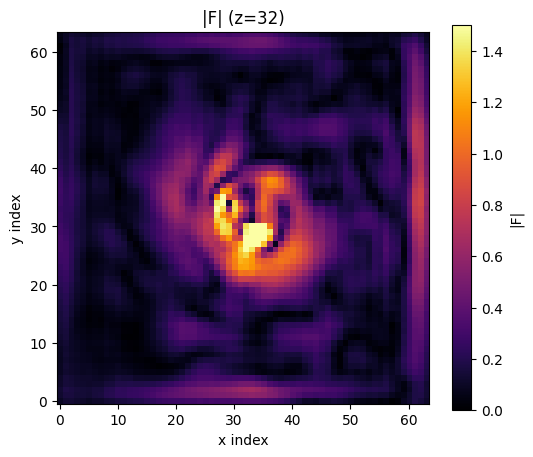

(64, 64)


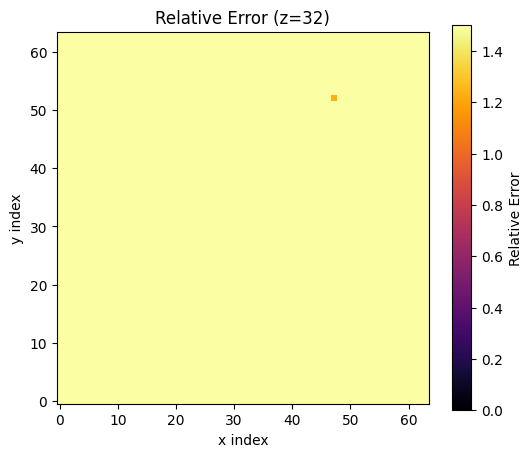

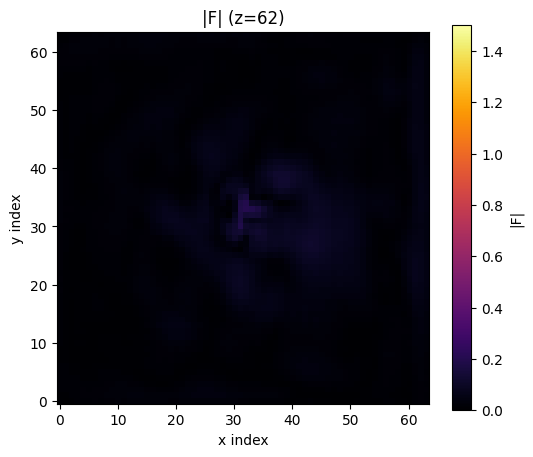

(64, 64)


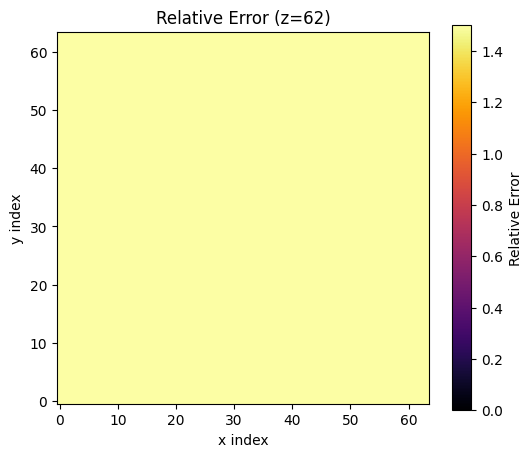

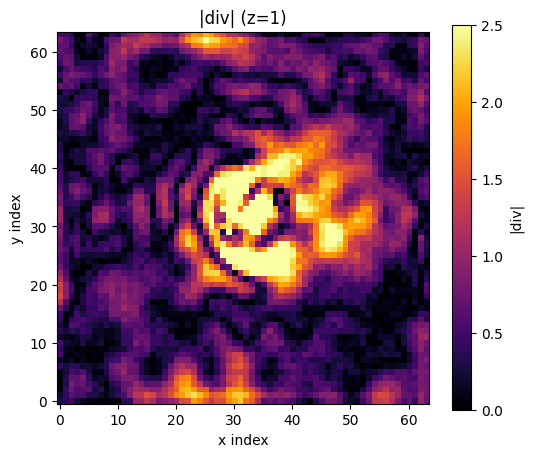

(64, 64)


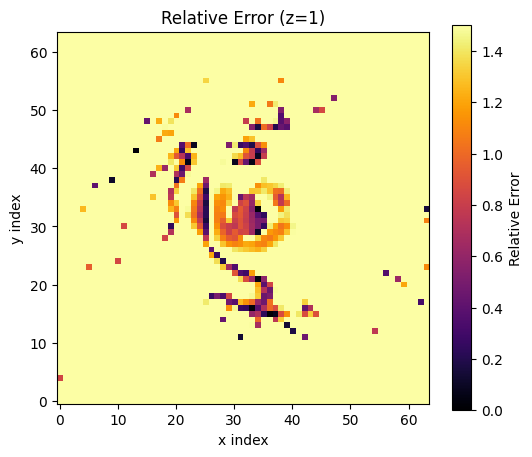

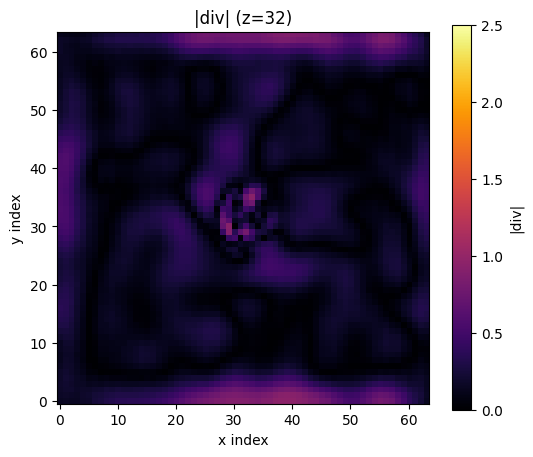

(64, 64)


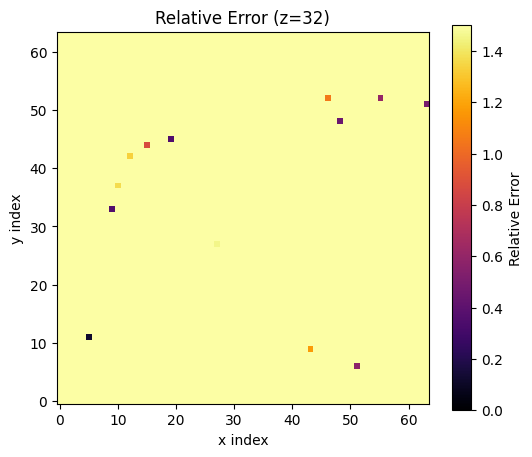

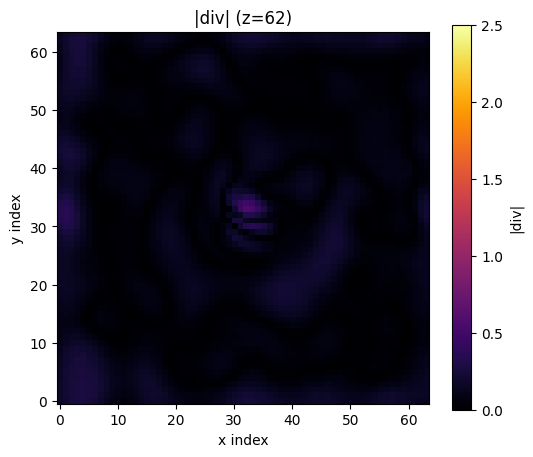

(64, 64)


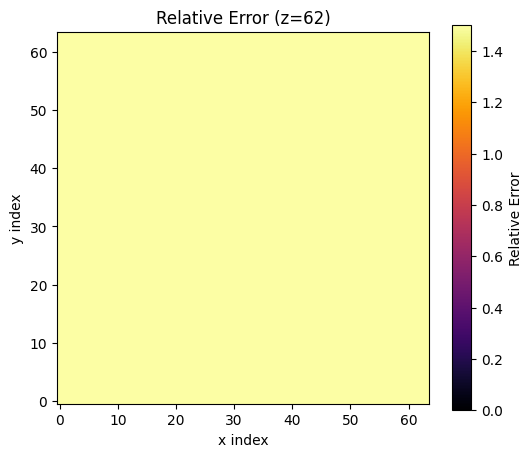

(64, 64)


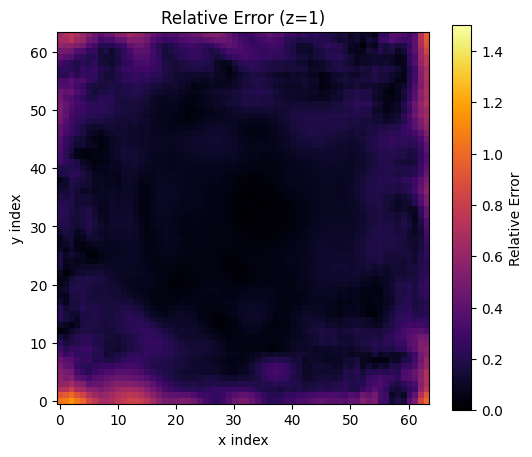

(64, 64)


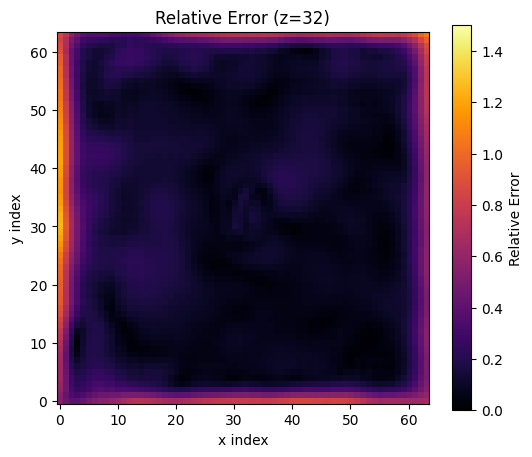

(64, 64)


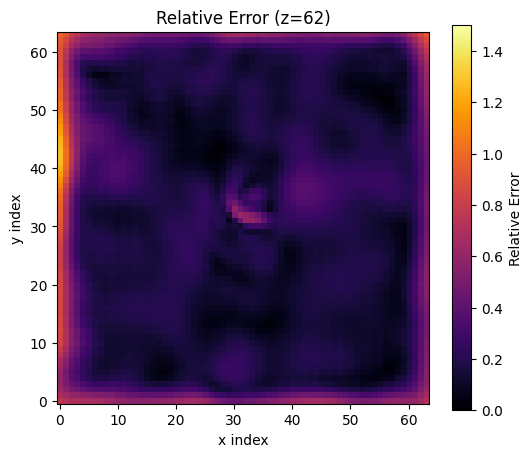

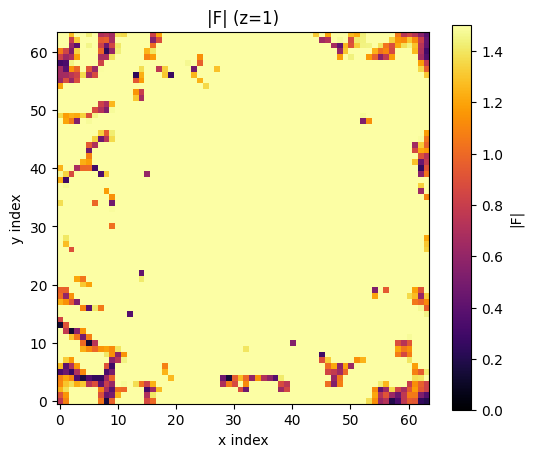

(64, 64)


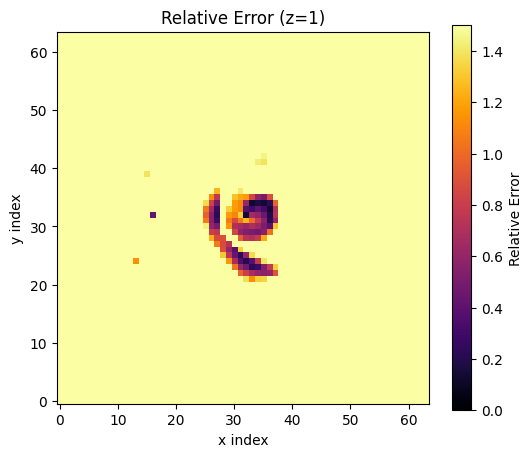

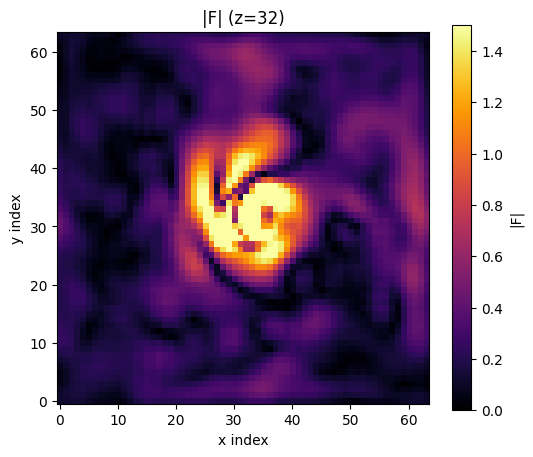

(64, 64)


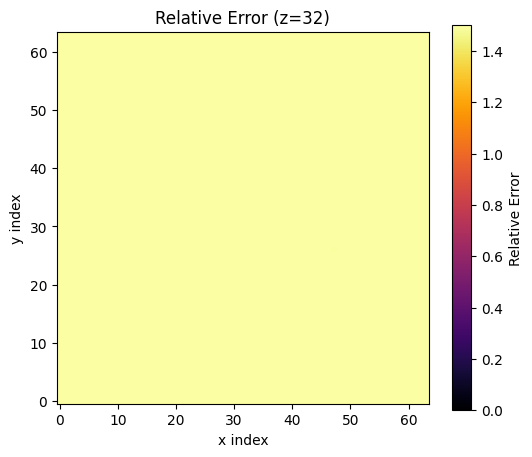

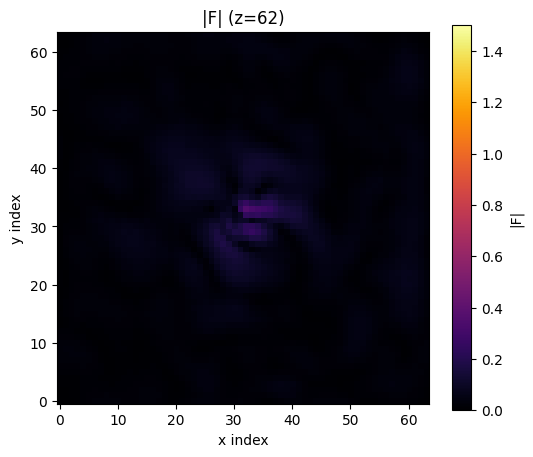

(64, 64)


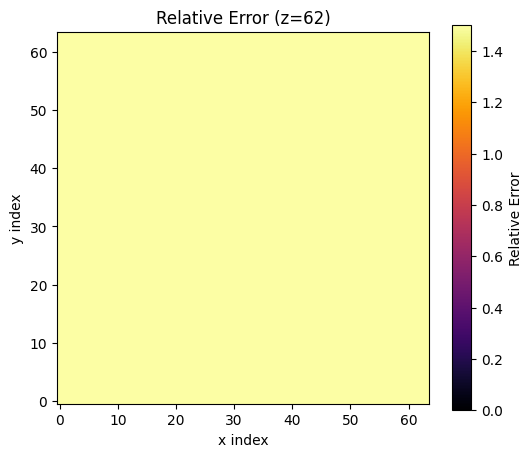

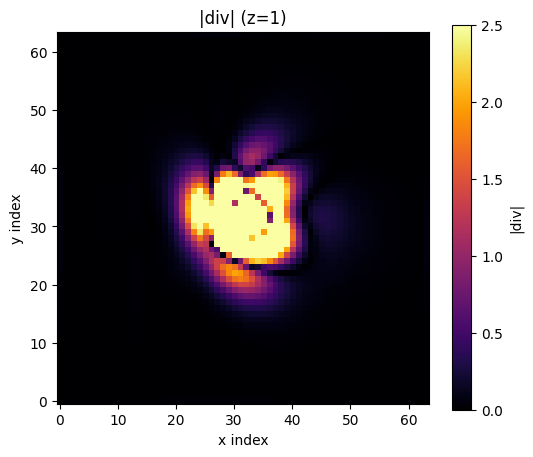

(64, 64)


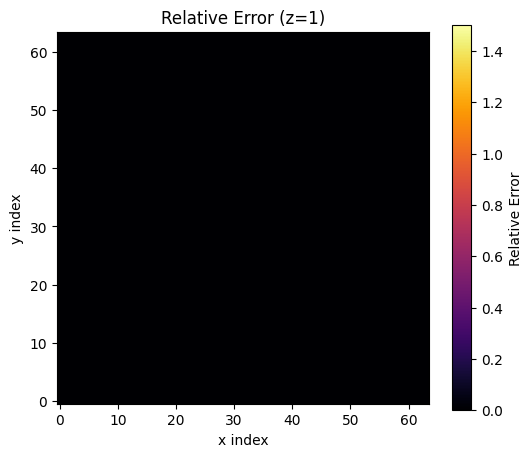

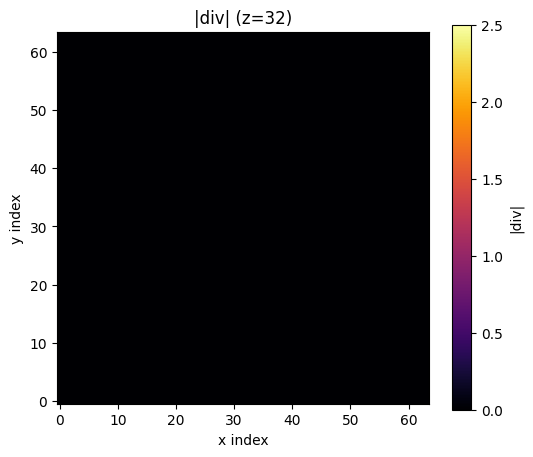

(64, 64)


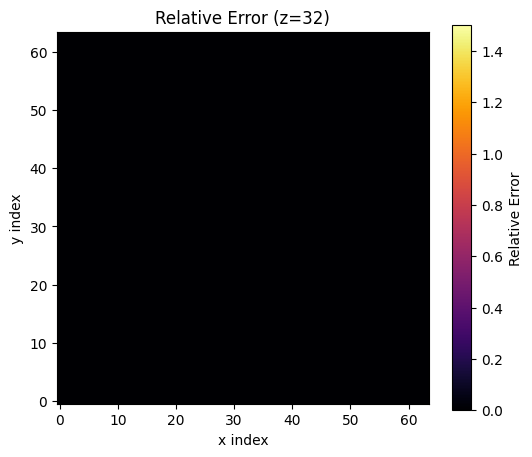

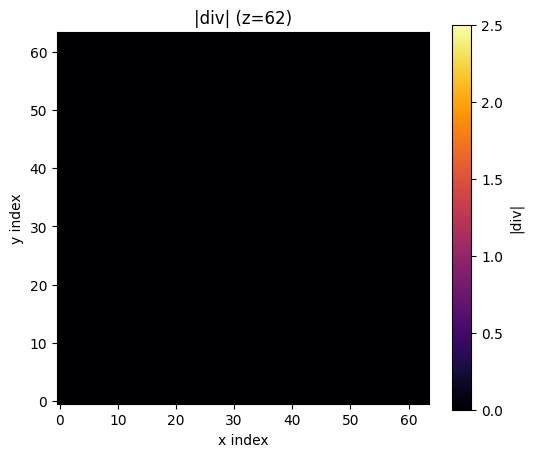

(64, 64)


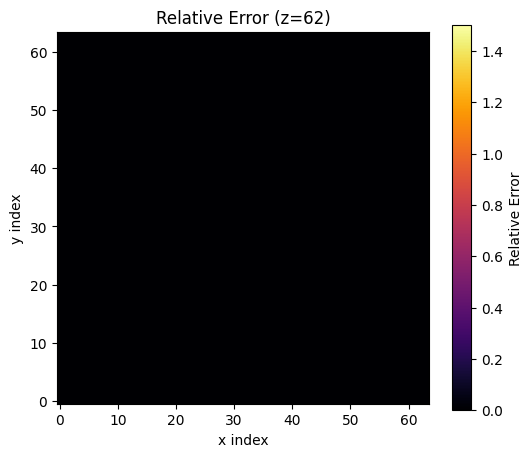

(64, 64)


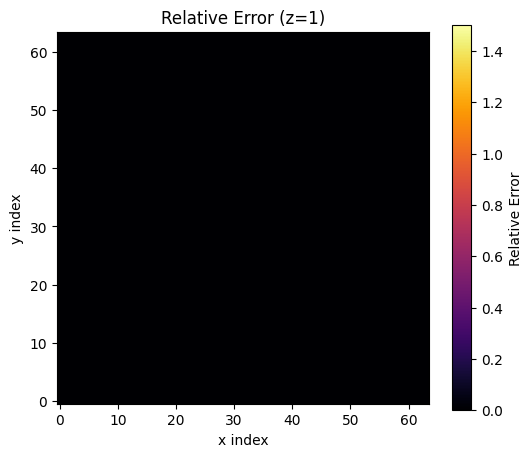

(64, 64)


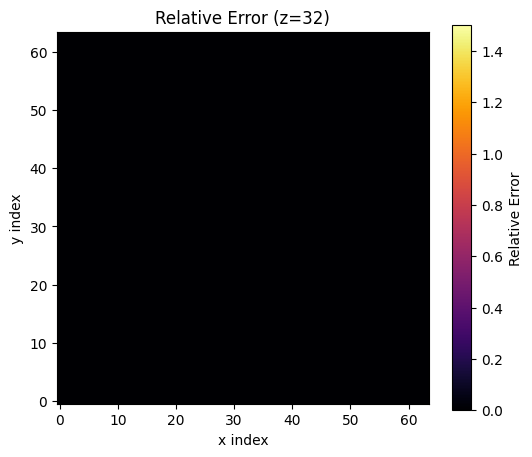

(64, 64)


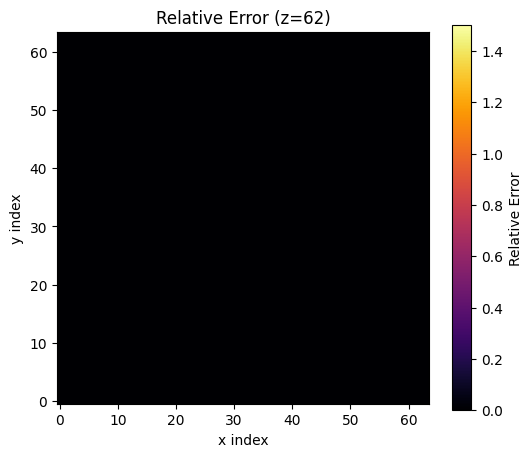

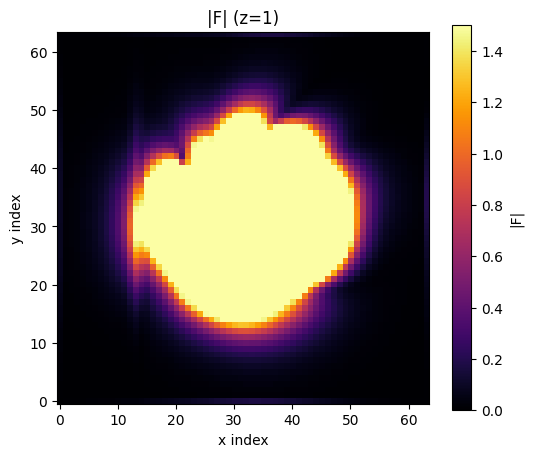

(64, 64)


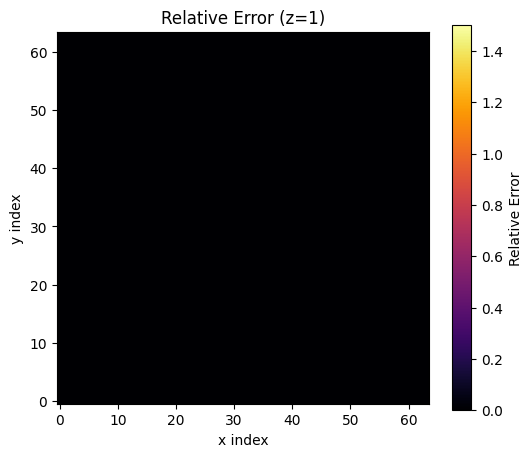

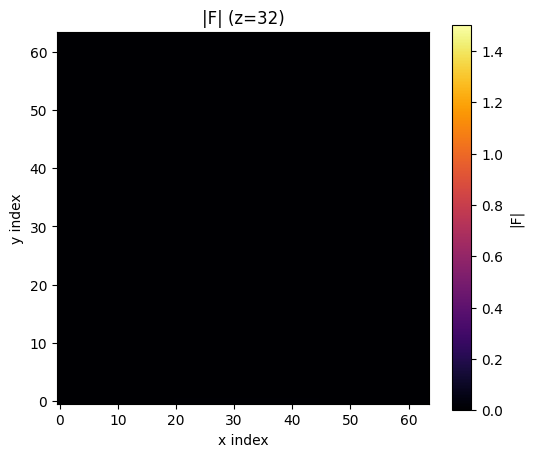

(64, 64)


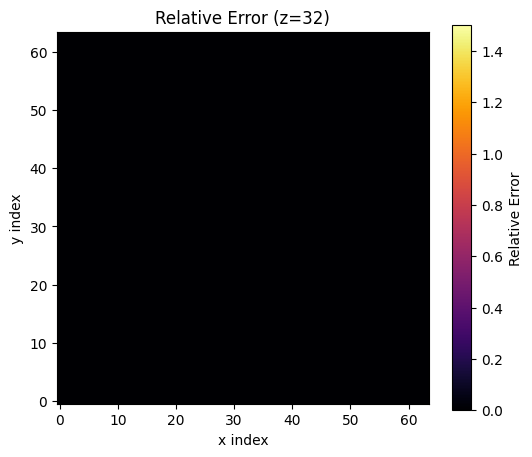

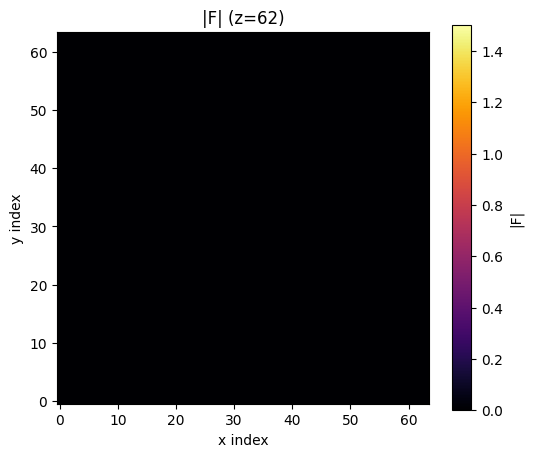

(64, 64)


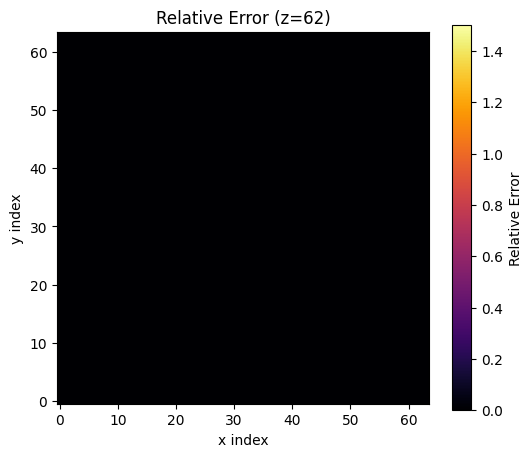

In [5]:
z_in = [1, 32, 62]
b_temp = b_array
for sample_b in b_temp:
    for i in z_in:
        #ij(sample_b, i)
        divb(sample_b, correct_data, i)
        pass
    for i in z_in:
        xyzmap_relative_error(sample_b, correct_data, i, 2)   
        #bitmap_relative_error(sample_b, correct_data, i, 0.5, 2) 
        pass
    for i in z_in:
        jxb(sample_b, correct_data, i)




In [6]:
def z_baffa():
    kx = np.fft.fftfreq(64, d=1.0) * 2*np.pi
    ky = np.fft.fftfreq(64, d=1.0) * 2*np.pi
    KX, KY = np.meshgrid(kx, ky, indexing='ij')
    K = np.sqrt(KX**2 + KY**2) + 1e-12  # 0除算防止
    K_mean = np.mean(K)
    return K_mean

print(z_baffa())

2.40437842247488
